In [1]:
import numpy as np
import h5py
import pandas as pd

import simweights
import nuflux

import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 26,  
    'text.color': 'black',  
    'xtick.labelsize': 26,  
    'ytick.labelsize': 26,  
    'legend.fontsize': 26,  
    'axes.labelsize': 26,  
})

In [2]:
def flux_val_SPL(energy): #per GeV per cm^2 per sr per s
    E=np.asarray(energy)
    #norm= 2.13 #MESE
    norm=1.66
    #gamma = 2.55 #MESE
    gamma= 2.53
    return 10**-18 * (norm)*((E/(100000.))**-gamma)

def flux_val_BPL(energy):
    norm = 2.27 # 1.66  
    gamma1 = 1.72#1.72  
    gamma2 = 2.83 #2.84 
    ebreak = 33419.5 #33162.3 
    new_weights = []
    for E in energy:
        weight = 0
        if E < ebreak:
            weight = norm* (E/ebreak)**(-gamma1)
        else:
            weight = norm* (E/ebreak)**(-gamma2)
        if ebreak > 100000:
            weight = 10**-18 * weight * (100000./ebreak)**(gamma1)
        else:
            weight = 10**-18 * weight * (100000./ebreak)**(gamma2)
        new_weights.append(weight)
    return np.array(new_weights)


In [56]:
def load_info(file_path, nfiles):
    hdf_store = pd.HDFStore(file_path, "r")
    print('IM OPEN')
   
    weighter = simweights.NuGenWeighter(hdf_store, nfiles=nfiles)
    #print(weighter)
    
    primary_energy = weighter.get_column("I3MCWeightDict", "PrimaryNeutrinoEnergy")
    primary_zenith = np.cos(weighter.get_column("I3MCWeightDict", "PrimaryNeutrinoZenith"))
    primary_azimuth = weighter.get_column("I3MCWeightDict", "PrimaryNeutrinoAzimuth")
    primary_type = weighter.get_column('I3MCWeightDict','PrimaryNeutrinoType')
    itype = weighter.get_column('I3MCWeightDict','InteractionType')
    ow = weighter.get_column('I3MCWeightDict','OneWeight')
    
    selection_pass = weighter.get_column("DNNDiffuse_v1.0.0_pass","value")
    
    pfit_energy = weighter.get_column("DNNDiffuse_v1.0.0_reco_features", "reco_energy")
    pfit_zenith = np.cos(weighter.get_column("DNNDiffuse_v1.0.0_reco_features", "reco_zenith"))
    pfit_azimuth = weighter.get_column("DNNDiffuse_v1.0.0_reco_features", "reco_azimuth")
    contained = weighter.get_column('DNNDiffuse_v1.0.0_reco_features','contained')
    partial = weighter.get_column('DNNDiffuse_v1.0.0_reco_features','partial')
    
    depo_energy = weighter.get_column("Deposited_Energy", "value")
    
    nuveto_total = weighter.get_column('nuveto','pf_dnn_cascade_selection_H3a_SIBYLL2_3c_total')
    nuveto_conv = weighter.get_column('nuveto','pf_dnn_cascade_selection_H3a_SIBYLL2_3c_conv')
    nuveto_pr = weighter.get_column('nuveto','pf_dnn_cascade_selection_H3a_SIBYLL2_3c_pr')
    
    cascade_BDT = weighter.get_column('DNNDiffuse_v1.0.0_reco_features','score_cascade_BDT')
    muon_BDT = weighter.get_column('DNNDiffuse_v1.0.0_reco_features','score_muon_BDT')
    
    pfit_z = weighter.get_column('DNNDiffuse_v1.0.0_reco_features','reco_z')
    pfit_y = weighter.get_column('DNNDiffuse_v1.0.0_reco_features','reco_y')
    pfit_x = weighter.get_column('DNNDiffuse_v1.0.0_reco_features','reco_x')
    
    run_id = weighter.get_column('I3EventHeader','Run')
    event_id = weighter.get_column('I3EventHeader','Event')
 
    
    astro_weight = weighter.get_weights(flux_val_BPL)
    astro_weight_SPL = weighter.get_weights(flux_val_SPL)
    
    prompt_weight = weighter.get_weights(nuflux.makeFlux('H3a_SIBYLL23C_pr'))
    conv_weight = weighter.get_weights(nuflux.makeFlux('H3a_SIBYLL23C_conv'))
    

    df = pd.DataFrame({
         "primary_energy": primary_energy,
         "depo_energy": depo_energy,
         "reco_energy": pfit_energy,

         "primary_zenith": primary_zenith,
         "reco_zenith": pfit_zenith,

         "primary_azimuth": primary_azimuth,
         "reco_azimuth": pfit_azimuth,

        'pf_total': nuveto_total,
        'pf_conv': nuveto_conv,
        'pf_pr': nuveto_pr,
        'cascade_BDT': cascade_BDT,
        'muon_BDT': muon_BDT,

        'astro_weight_BPL': astro_weight,
        'astro_weight_SPL': astro_weight_SPL,
        'prompt_weight': prompt_weight,
        'conv_weight': conv_weight,
        'reco_z': pfit_z,
        'reco_y': pfit_y,
        'reco_x': pfit_x,
        'run_id':run_id,
        'event_id':event_id,

        'type':primary_type,
        'interaction_type':itype,
        'contained':contained,
        'partial':partial,
        'ow':ow,
        
        'selection_pass':selection_pass,

    })
    
    print('I CLOSED')
    hdf_store.close()
    
    return df

In [57]:
def load_infod(file_path, nfiles):
    hdf_store = pd.HDFStore(file_path, "r")
    print('IM OPEN')
   
    weighter = simweights.NuGenWeighter(hdf_store, nfiles=nfiles)
    #print(weighter)
    
    primary_energy = weighter.get_column("I3MCWeightDict", "PrimaryNeutrinoEnergy")
    primary_zenith = np.cos(weighter.get_column("I3MCWeightDict", "PrimaryNeutrinoZenith"))
    primary_azimuth = weighter.get_column("I3MCWeightDict", "PrimaryNeutrinoAzimuth")
    primary_type = weighter.get_column('I3MCWeightDict','PrimaryNeutrinoType')
    depo_energy = weighter.get_column("Deposited_Energy", "value")
    #print('123')
    pfit_energy = weighter.get_column("PreferredFit", "energy")
    pfit_zenith = np.cos(weighter.get_column("PreferredFit", "zenith"))
    pfit_azimuth = weighter.get_column("PreferredFit", "azimuth")
    
    egen_energy = weighter.get_column("EventGeneratorSelectedRecoNN_I3Particle", "energy")
    #print('abc')
    egen_zenith = np.cos(weighter.get_column("EventGeneratorSelectedRecoNN_I3Particle", "zenith"))
    egen_azimuth = weighter.get_column("EventGeneratorSelectedRecoNN_I3Particle", "azimuth")
    
    nuveto_total = weighter.get_column('nuveto','pf_dnn_cascade_selection_H3a_SIBYLL2_3c_total')
    nuveto_conv = weighter.get_column('nuveto','pf_dnn_cascade_selection_H3a_SIBYLL2_3c_conv')
    #print('dont mind me')
    nuveto_pr = weighter.get_column('nuveto','pf_dnn_cascade_selection_H3a_SIBYLL2_3c_pr')
    
    cascade_BDT = weighter.get_column('BDT_bdt_max_depth_4_n_est_1000lr_0.01_seed_3_train_size_50','pred_001')
    muon_BDT = weighter.get_column('BDT_bdt_max_depth_4_n_est_2000lr_0_02_seed_3_train_size_50','pred_001')
    
    pfit_z = weighter.get_column('PreferredFit','z')
    #p#rint('denhdenhdenh')
    pfit_y = weighter.get_column('PreferredFit','y')
    pfit_x = weighter.get_column('PreferredFit','x')
    
    QTot = weighter.get_column('Homogenized_QTot','value')
    #print('almost there')
    run_id = weighter.get_column('I3EventHeader','Run')
    event_id = weighter.get_column('I3EventHeader','Event')
    itype = weighter.get_column('I3MCWeightDict','InteractionType')
    
    
    astro_weight = weighter.get_weights(flux_val_BPL)
    astro_weight_SPL = weighter.get_weights(flux_val_SPL)
    #print('whoo whoo whoo')
    prompt_weight = weighter.get_weights(nuflux.makeFlux('H3a_SIBYLL23C_pr'))
    conv_weight = weighter.get_weights(nuflux.makeFlux('H3a_SIBYLL23C_conv'))
    
    contained = weighter.get_column('contained','value')
    partial = weighter.get_column('partial','value')
    
    
    ow = weighter.get_column('I3MCWeightDict','OneWeight')

    #print('trademarked Jackson 5')
    df = pd.DataFrame({
         "primary_energy": primary_energy,
         "depo_energy": depo_energy,
         "pfit_energy": pfit_energy,
#          "egen_energy": egen_energy,
         "primary_zenith": primary_zenith,
         "pfit_zenith": pfit_zenith,
#         "egen_zenith": egen_zenith,
         "primary_azimuth": primary_azimuth,
         "pfit_azimuth": pfit_azimuth,
#         "egen_azimuth": egen_azimuth,
         'pf_total': nuveto_total,
         'pf_conv': nuveto_conv,
         'pf_pr': nuveto_pr,
         'cascade_BDT': cascade_BDT,
         'muon_BDT': muon_BDT,
        #'weighter': weighter,
        'astro_weight_BPL': astro_weight,
        'astro_weight_SPL': astro_weight_SPL,
        'prompt_weight': prompt_weight,
        'conv_weight': conv_weight,
        'pfit_z': pfit_z,
        'pfit_y': pfit_y,
        'pfit_x': pfit_x,
        'run_id':run_id,
        'event_id':event_id,
        'Qtot' :QTot,
        'type':primary_type,
        'interaction_type':itype,
        'contained':contained,
        'partial':partial,
        'ow':ow,

    })
    
    print('I CLOSED')
    hdf_store.close()
    
    return df

In [59]:
##numu
# path = '23521_0000000-0000999_module.hdf5'
# numfiles = 0
# df_23521_0_all = load_info(path,numfiles)

path = '23522_0000000-0000999_module.hdf5'
numfiles = 10
df_23522_0_all = load_info(path,numfiles)


path = '23523_0000000-0000999_module.hdf5'
numfiles = 10
df_23523_0_all = load_info(path,numfiles)

path = '23523_0001000-0001999_module.hdf5'
numfiles = 10
df_23523_1_all = load_info(path,numfiles)

##nue
path = '23524_0000000-0000999_module.hdf5'
numfiles = 2
df_23524_0_all = load_info(path,numfiles)

path = '23525_0000000-0000999_module.hdf5'
numfiles = 10
df_23525_0_all = load_info(path,numfiles)


path = '23526_0000000-0000999_module.hdf5'
numfiles = 10
df_23526_0_all = load_info(path,numfiles)

path = '23526_0001000-0001999_module.hdf5'
numfiles = 10
df_23526_1_all = load_info(path,numfiles)

##nutau
path = '23527_0000000-0000999_module.hdf5'
numfiles = 10
df_23527_0_all = load_info(path,numfiles)

path = '23528_0000000-0000999_module.hdf5'
numfiles = 10
df_23528_0_all = load_info(path,numfiles)


path = '23529_0000000-0000999_module.hdf5'
numfiles = 10
df_23529_0_all = load_info(path,numfiles)

path = '23529_0001000-0001999_module.hdf5'
numfiles = 10
df_23529_1_all = load_info(path,numfiles)


numuall = pd.concat([df_23522_0_all,df_23523_0_all,df_23523_1_all],ignore_index=True)
nueall = pd.concat([df_23524_0_all,df_23525_0_all,df_23526_0_all,df_23526_1_all],ignore_index=True)
nutauall = pd.concat([df_23527_0_all,df_23528_0_all,df_23529_0_all,df_23529_1_all],ignore_index=True)
dfall = pd.concat([numuall,nueall,nutauall],ignore_index=True)

IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED


In [60]:
##numu
# path = '23521_0000000-0000999_delete.hdf5'
# numfiles = 0
# df_23521_0_alld = load_info(path,numfiles)

path = '23522_0000000-0000999_delete.hdf5'
numfiles = 10
df_23522_0_alld = load_infod(path,numfiles)


path = '23523_0000000-0000999_delete.hdf5'
numfiles = 10
df_23523_0_alld = load_infod(path,numfiles)

path = '23523_0001000-0001999_delete.hdf5'
numfiles = 10
df_23523_1_alld = load_infod(path,numfiles)

##nue
path = '23524_0000000-0000999_delete.hdf5'
numfiles = 2
df_23524_0_alld = load_infod(path,numfiles)

path = '23525_0000000-0000999_delete.hdf5'
numfiles = 10
df_23525_0_alld = load_infod(path,numfiles)


path = '23526_0000000-0000999_delete.hdf5'
numfiles = 10
df_23526_0_alld = load_infod(path,numfiles)

path = '23526_0001000-0001999_delete.hdf5'
numfiles = 10
df_23526_1_alld = load_infod(path,numfiles)

##nutau
path = '23527_0000000-0000999_delete.hdf5'
numfiles = 10
df_23527_0_alld = load_infod(path,numfiles)

path = '23528_0000000-0000999_delete.hdf5'
numfiles = 10
df_23528_0_alld = load_infod(path,numfiles)


path = '23529_0000000-0000999_delete.hdf5'
numfiles = 10
df_23529_0_alld = load_infod(path,numfiles)

path = '23529_0001000-0001999_delete.hdf5'
numfiles = 10
df_23529_1_alld = load_infod(path,numfiles)

numualld = pd.concat([df_23522_0_alld,df_23523_0_alld,df_23523_1_alld],ignore_index=True)
nuealld = pd.concat([df_23524_0_alld,df_23525_0_alld,df_23526_0_alld,df_23526_1_alld],ignore_index=True)
nutaualld = pd.concat([df_23527_0_alld,df_23528_0_alld,df_23529_0_alld,df_23529_1_alld],ignore_index=True)
dfalld = pd.concat([numualld,nuealld,nutaualld],ignore_index=True)

IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED
IM OPEN
I CLOSED


In [61]:
mask = [val == True for val in dfall['selection_pass']]
df = dfall[mask]

In [63]:
mask1 = [val == True for val in dfalld['partial']]
mask2 = [val <1e4 for val in dfalld['pfit_energy']]
mask = np.logical_and(mask1,mask2)
dfd = dfalld[~mask]

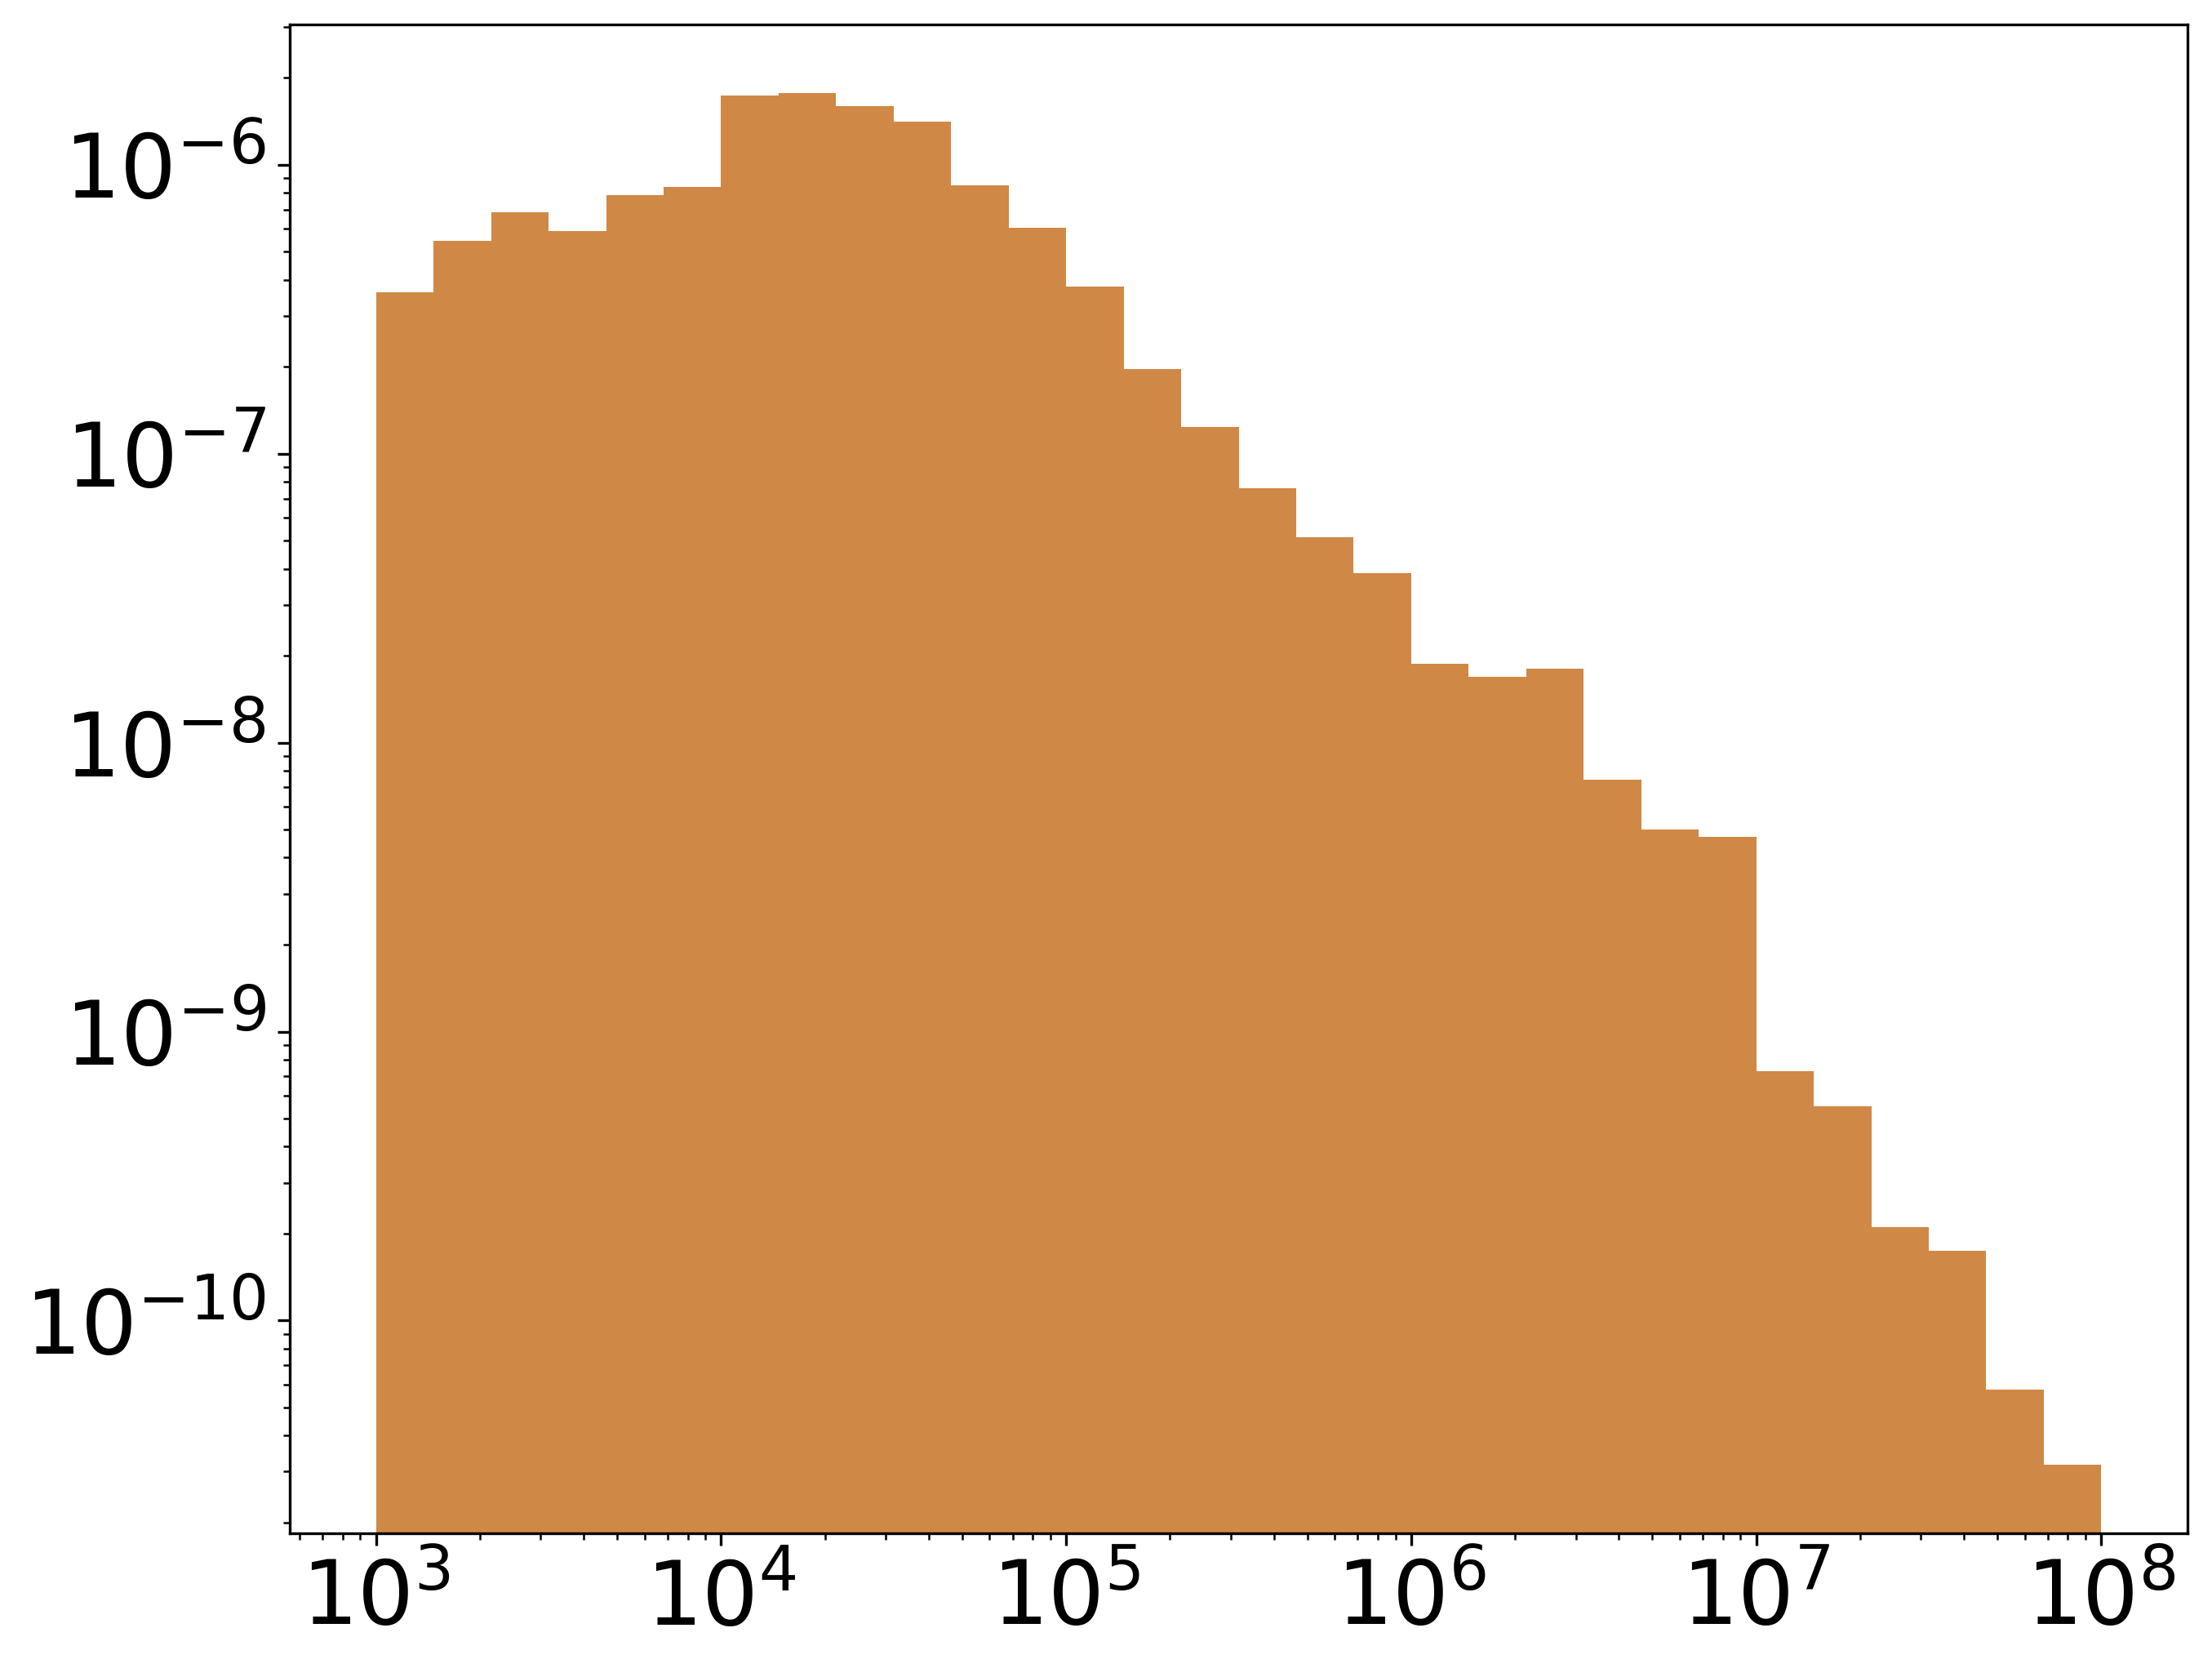

In [65]:
fig,ax = plt.subplots(1,1,dpi=300,figsize=(10,8))
bins = np.logspace(3,8,31)
plt.hist(df['reco_energy'],weights=df['astro_weight_BPL'],bins=bins,alpha=.7)
plt.hist(dfd['pfit_energy'],weights=dfd['astro_weight_BPL'],bins=bins,alpha=.7)
plt.xscale('log')
plt.yscale('log')